# Exercise 1.1: Estimate $\pi$ with Monte Carlo (*total: 7 points*)

In [1]:
### Necessary Python libraries
import IPython
assert IPython.version_info[0] >= 3, "Your version of IPython is too old, please update it."
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
%matplotlib inline

In [2]:
### If you wish, you can import more libraries here

---

## Exercise 1.1-a (1pt)

Implement the function `estimate_pi(ng, N)`, which estimates $\pi$ by “shooting” (i.e., drawing random numbers) $N$ times uniformly on a square and counting the number of points hitting a disc target: the ratio of hits to $N$ corresponds to the ratio of the areas of the target to the area you shoot on.

<div align="center">
  <img src="compute_pi_with_MC.svg" alt="drawing" width="200"/>
</div>

In [3]:
def estimate_pi(rng, N):
    # YOUR CODE HERE
    def _within_radius(coord):
        return np.sqrt(coord[0]**2 + coord[1]**2) <= 1
    count = 0
    for _ in range(N):
        coord = rng.random(2)
        if _within_radius(coord):
            count += 1
    estimate = 4 * count / N
    return estimate



In [4]:
# Testing
# YOUR CODE HERE
rng = np.random.default_rng(52)
est_pi = estimate_pi(rng, 10000)

print(est_pi)

3.14


In [5]:
# 1.1-a tests
result_test = estimate_pi(np.random.default_rng(42), 1)
assert type(result_test) is float or type(result_test) is np.float64, f"Expected a result of type float, but the result type is {type(result_test)}"
result_test = estimate_pi(np.random.default_rng(42), 1000)
assert np.isclose(result_test, np.pi, atol=2.e-1), f"The estimation for N=1000 samples should already be close to pi, but is {result_test}."
del result_test

---

## Exercise 1.1-b (1pt)

Implement the function `estimate_average_error(rng, N, N_bins)`, estimating the average error for given $N$ by repeating 1.1-a a few ($N_\text{bins}$) times.

> **Optional:** Additionally compute the *variance*
> \begin{equation*}
\text{VAR}(x_1, x_2, \dots, x_{N_\text{bins}}) = \frac{\sum_{n=1}^{N_\text{bins}}|x_n-\bar{x}|}{N_\text{bins}},
\end{equation*}
> where $x_n$ is the estimated value of $\pi$ from bin $n$ and $\bar{x}$ is the average of all bins.

In [6]:
def estimate_average_error(rng, N, N_bins):

    # YOUR CODE HERE
    ave_error = 0
    for _ in range(N_bins):
        est_pi = estimate_pi(rng, N)
        ave_error += np.abs(np.pi - est_pi)
    return ave_error/N_bins

def estimate_variance(rng, N, N_bins):
    est_pi_list = []
    for _ in range(N_bins):
        est_pi_list.append(estimate_pi(rng, N))
    ave_est = np.mean(est_pi_list)
    var = 0
    for est in est_pi_list:
        var += np.abs(est-ave_est)
    return var / N_bins

In [7]:
# Testing
# YOUR CODE HERE
rng = np.random.default_rng(42)
N = 1000
N_bins = 10

error = estimate_average_error(rng, N, N_bins)

var = estimate_variance(rng, N, N_bins)

print(error)
print(var)

0.0484814692820414
0.033439999999999956


In [8]:
# 1.1-b tests
result_test = estimate_average_error(np.random.default_rng(42), 1000, 100)
assert type(result_test) is float or type(result_test) is np.float64, f"Expected a result of type float, but the result type is {type(result_test)}"
assert result_test < 0.1, f"1000 samples should result in a mean error < 0.05, but the mean error is {result_test}."
del result_test

---

## Exercise 1.1-c (2pt)

Plot the average error versus $N$ on a log-log scale. How does the error scale?


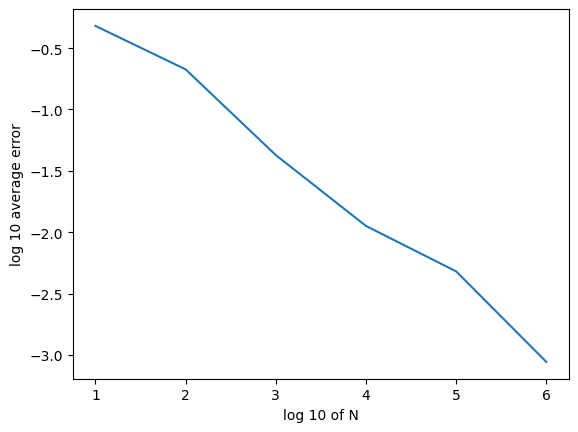

In [9]:
# YOUR CODE HERE
rng = np.random.default_rng(32)
N_bins = 10

log_N_list = np.array(list(range(1,7)))

log_ave_error_list = []
for log_N in log_N_list:
    N = 10 ** log_N
    log_ave_error_list.append(np.log10(estimate_average_error(rng, N, N_bins)))

plt.xlabel("log 10 of N")
plt.ylabel("log 10 average error")
plt.plot(log_N_list, log_ave_error_list)
plt.show()

Linear in Log plot means exponential decrease.

---

Now we want to generalize our problem to $d$-dimensions.

## Exercise 1.1-d (1pt)

Generalize your code to estimate the volume of a $d$-dimensional sphere of radius $r=1$ using Monte Carlo sampling by implementing the function `estimate_volume_d_sphere(rng, N, d)`.

In [10]:
def estimate_volume_d_sphere(rng, N, d):
    # YOUR CODE HERE
    def _within_radius(coord):
        distance = 0
        for element in coord:
            distance += element ** 2
        return np.sqrt(distance) <= 1

    count = 0
    for _ in range(N):
        coord = rng.random(d)
        if _within_radius(coord):
            count += 1

    vol = 2 ** d * count / N
    return vol

In [11]:
# Testing
# YOUR CODE HERE
rng = np.random.default_rng(42)
vol = estimate_volume_d_sphere(rng, 10000,4)
print(vol)

4.9376


In [12]:
# 1.1-d tests
result_test = estimate_volume_d_sphere(np.random.default_rng(42), 10000, 3)
assert type(result_test) is float or type(result_test) is np.float64, f"Expected a result of type float, but the result type is {type(result_test)}"
assert np.isclose(result_test, 4.189, atol=0.5)
assert np.isclose(estimate_volume_d_sphere(np.random.default_rng(42), 10000, 4), 4.935, atol=1.0)
del result_test

---

## Exercise 1.1-e (2pt)

Plot the average error versus $N$ on a log-log-scale for different values of $d$. How does the computational cost scale with the of dimension $d$ for a fixed value of $N$? How does the error of the estimates scale for $d$ and $N$? Write down your answers in the markdown cell below.

> **Note:** To compute the error of your estimate you can compare to the [exact value](https://en.wikipedia.org/wiki/Volume_of_an_n-ball)
> \begin{equation*}
V_{\text{d-sphere}} = \frac{\pi^{d/2}}{\Gamma\left(\frac{d}{2}+1\right)}.
\end{equation*}
> The value of the $\Gamma$-function can be obtained using `scipy.special.gamma`.

> **Hint:** To see the scaling of the computational cost and the scaling of the error with $d$ at fixed $N$ it may be helpful (but not required) to produce additional plots.


In [13]:
def compute_volume_sphere_exact(d):
    return np.pi**(d/2)/scipy.special.gamma(d/2+1)

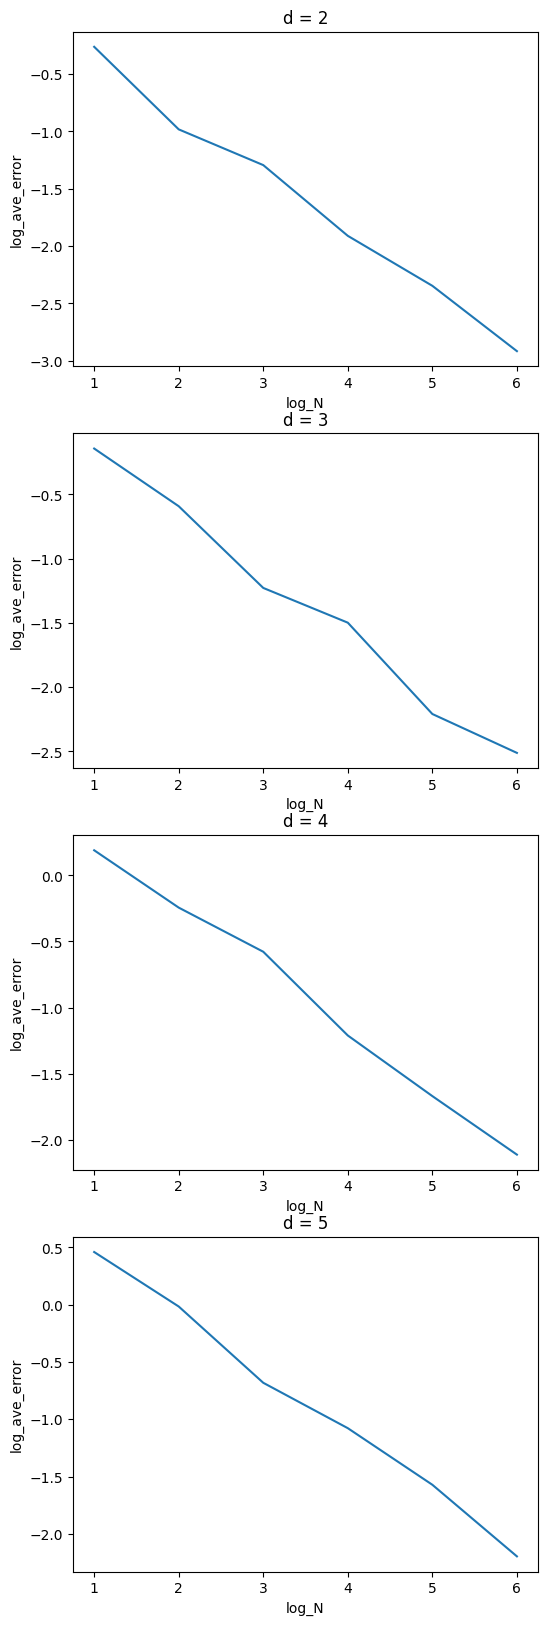

In [14]:
# YOUR CODE HERE
# Average Error versus N log-log scale for different values of d
def average_error_sphere(rng, N, N_bins, d):
    ave_error = 0
    for _ in range(N_bins):
        ave_error += np.abs(compute_volume_sphere_exact(d) - estimate_volume_d_sphere(rng, N, d) )
    return ave_error / N_bins

def log_ave_error_list(rng, N_bins, d, log_N_list):
    log_ave_error_list = []
    for log_N in log_N_list:
        N = 10 ** log_N
        log_ave_error_list.append(np.log10(average_error_sphere(rng, N, N_bins, d)))
    return log_ave_error_list

rng = np.random.default_rng(42)
d_list = list(range(2,6))
N_bins = 10

log_N_list = np.array(list(range(1,7)))

fig, ax = plt.subplots(len(d_list),1, figsize=(6,20))

for i in range(len(d_list)):
    d = d_list[i]

    ax[i].plot(log_N_list, log_ave_error_list(rng, N_bins, d, log_N_list))
    ax[i].set_title(f"d = {d}")
    ax[i].set_xlabel("log_N")
    ax[i].set_ylabel("log_ave_error")



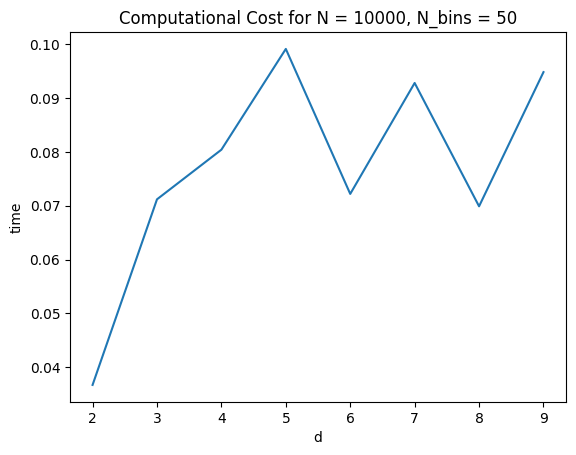

In [17]:
# Computational Cost scale to d with fixed N
# Measure runtime
import time

def average_cost(rng, N, N_bins, d):
    ave = 0
    for _ in range(N_bins):
        t0 = time.time()
        estimate_volume_d_sphere(rng, N, d)
        ave += time.time() - t0
    return ave / N_bins

N = 10000
N_bins = 50
times = []
d_list = list(range(2, 10))

for d in d_list:
    times.append(average_cost(rng, N, N_bins, d))

plt.plot(d_list, times)
plt.title(f"Computational Cost for N = {N}, N_bins = {N_bins}")
plt.xlabel("d")
plt.ylabel("time")
plt.show()


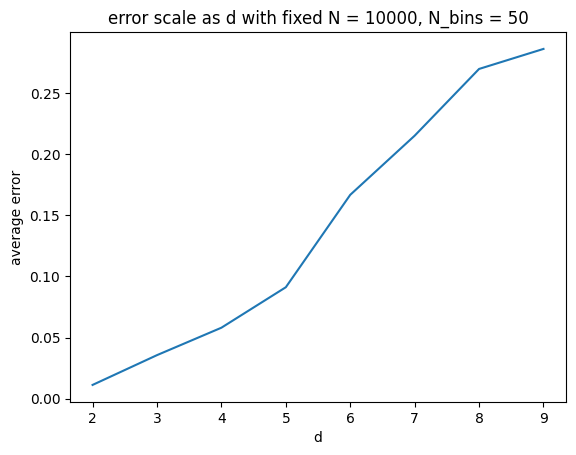

In [16]:
# Error of the estimates scale as d and N
# Error scale as d with fixed N
N_bins = 50
N_fixed = 10000
d_list = list(range(2, 10))
error_list = []

for d in d_list:
    error_list.append(average_error_sphere(rng, N_fixed, N_bins, d))

plt.plot(d_list, error_list)
plt.xlabel("d")
plt.ylabel("average error")
plt.title(f"error scale as d with fixed N = {N_fixed}, N_bins = {N_bins}")
plt.show()



for different d values, average error decrease exponentianly with increasing N. For fixed N value, error scales linearly with increasing dimensions. This comes from the fact that more random variables are sampled for higher dimensions. Computational Cost also increases linearly with increasing values of dimension d. Also caused by increasing number of sampling